In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
from mhn import MHN
from tqdm.auto import tqdm

In [ ]:
class MHN(nn.Module):
    def __init__(self, input_size, num_patterns, log_beta_mean=0.0, log_beta_std=0.0, learn_biases=True):
        super().__init__()
        self.input_size = input_size
        self.num_patterns = num_patterns

        self.patterns = nn.Parameter(
            torch.randn(num_patterns, input_size),
            requires_grad=True
        )
        self.biases = nn.Parameter(
            torch.zeros(num_patterns),
            requires_grad=learn_biases
        )
        
        # Better as buffers, not Parameters
        self.register_buffer("running_log_beta_mean", torch.tensor(log_beta_mean))
        self.register_buffer("running_log_beta_std", torch.tensor(log_beta_std))
        self.register_buffer("num_calls", torch.tensor(1, dtype=torch.long))
    @torch.no_grad() 
    def get_beta_crit(self, eps=1e-12):
        w0 = torch.softmax(self.biases, dim=0)  # (K,)
        u = torch.sqrt(w0)

        K = self.patterns.shape[0]
        I = torch.eye(K, device=self.patterns.device, dtype=self.patterns.dtype)

        proj = I - torch.outer(u, u)

        W_half = torch.diag(torch.sqrt(w0))
        half_stab_matrix = proj @ W_half @ self.patterns

        stability_matrix = half_stab_matrix @ half_stab_matrix.T

        vals = torch.linalg.eigvalsh(stability_matrix)
        beta = 1.0 / vals.max().clamp_min(eps)

        return beta

    def init_with_data(self, x, std_fraction):
        with torch.no_grad():
            kmeans = KMeans(n_clusters=self.num_patterns, random_state=0).fit(x.cpu().numpy())
            labels = kmeans.labels_
            label_counts = np.bincount(labels)
            label_proportions = label_counts / label_counts.sum()
            self.biases.copy_(torch.log(torch.tensor(label_proportions).float() + 1e-8))
            self.patterns.copy_(torch.from_numpy(kmeans.cluster_centers_).to(self.patterns.device))
            beta_c = self.get_beta_crit()
            self.running_log_beta_mean = torch.log(beta_c)
            self.running_log_beta_std = torch.log(beta_c*std_fraction)
    @torch.no_grad()
    def update_beta_stats_data(self, x, reset=False):
        if reset:
            self.running_log_beta_mean.zero_()
            self.running_log_beta_std.zero_()
            self.num_calls.zero_()

        w0 = torch.ones(x.shape[0], device=x.device)/x.shape[0]
        u = torch.sqrt(w0)
        proj = torch.eye(x.shape[0], device=x.device) - torch.outer(u, u)

        half_stab_matrix = proj @  torch.diag_embed(w0) @ x
        stability_matrix = half_stab_matrix @ half_stab_matrix.T
        vals, vecs = torch.linalg.eigh(stability_matrix)
        beta = 1.0/vals.max()
        log_beta = torch.log(beta)

        old_num_calls = self.num_calls.to(log_beta.dtype)

        old_mean = self.running_log_beta_mean
        old_std = self.running_log_beta_std

        # old population variance
        old_var = old_std.square()

        # update mean
        new_mean = (old_num_calls * old_mean + log_beta) / (old_num_calls + 1.0)

        # update second moment:
        # E[x^2] = Var[x] + E[x]^2
        old_second_moment = old_var + old_mean.square()
        new_second_moment = (
            old_num_calls * old_second_moment + log_beta.square()
        ) / (old_num_calls + 1.0)

        new_var = (new_second_moment - new_mean.square()).clamp_min(0.0)
        new_std = torch.sqrt(new_var)
        self.running_log_beta_mean.copy_(new_mean)
        self.running_log_beta_std.copy_(new_std)
        self.num_calls += 1

    

    @torch.no_grad()
    def update_beta_stats(self):
        w0 = torch.softmax(self.biases, dim=0)  # (K,)
        u = torch.sqrt(w0)
        proj = torch.eye(self.num_patterns, device=self.patterns.device) - torch.outer(u, u)

        half_stab_matrix = proj @  torch.diag_embed(w0) @ self.patterns
        stability_matrix = half_stab_matrix @ half_stab_matrix.T
        vals, vecs = torch.linalg.eigh(stability_matrix)
        beta = 1.0/vals.max()
        log_beta = torch.log(beta)

        old_num_calls = self.num_calls.to(log_beta.dtype)

        old_mean = self.running_log_beta_mean
        old_std = self.running_log_beta_std

        # old population variance
        old_var = old_std.square()

        # update mean
        new_mean = (old_num_calls * old_mean + log_beta) / (old_num_calls + 1.0)

        # update second moment:
        # E[x^2] = Var[x] + E[x]^2
        old_second_moment = old_var + old_mean.square()
        new_second_moment = (
            old_num_calls * old_second_moment + log_beta.square()
        ) / (old_num_calls + 1.0)

        new_var = (new_second_moment - new_mean.square()).clamp_min(0.0)
        new_std = torch.sqrt(new_var)
        self.running_log_beta_mean.copy_(new_mean)
        self.running_log_beta_std.copy_(new_std)
        self.num_calls += 1

    @torch.no_grad()
    def center_biases(self):
        with torch.no_grad():
            self.biases -= self.biases.mean()
    def forward(self, x, num_betas):
        """
        x: (N, D)
        returns scalar loss
        """
        N, D = x.shape

        betas = torch.exp(
            torch.randn(
                num_betas,
                device=x.device,
                dtype=x.dtype,
            ) * self.running_log_beta_std
            + self.running_log_beta_mean
        )  # (B,)

        # Q_b potentials: 1/2 ||Q_b||^2
        patterns_pot = 0.5 * torch.sum(self.patterns**2, dim=1)  # (K,)

        # P_mu . Q_b
        dot_prods = x @ self.patterns.T  # (N, K)

        # data term:
        # alpha_b + beta Q_b . x_mu
        logits_data = (
            self.biases[None, None, :]                       # (1, 1, K)
            + betas[:, None, None] * dot_prods[None, :, :]    # (B, N, K)
        )

        logZ_data = torch.logsumexp(logits_data, dim=-1)      # (B, N)

        # normalization term:
        # alpha_b + beta/2 ||Q_b||^2
        logits_norm = (
            self.biases[None, :]                              # (1, K)
            + betas[:, None] * patterns_pot[None, :]          # (B, K)
        )

        logZ_norm = torch.logsumexp(logits_norm, dim=-1)      # (B,)
        return logZ_data, logZ_norm

In [2]:
D_x = 1.0
D_y = 0.5
tau_y = 1.0
k = 0.1
N = 1000000
dt = 1e-3
x = torch.zeros(N)
y = torch.zeros(N)
eta_x = torch.sqrt(torch.tensor(2*D_x*dt))*torch.randn(N)
eta_y = torch.sqrt(torch.tensor(2*D_y*dt))*torch.randn(N)
for i in tqdm(range(1,N)):
    force_x = x[i-1] - x[i-1]**3 + k*(y[i-1]-x[i-1])
    force_y = -y[i-1]/tau_y + k*(x[i-1]-y[i-1])
    x[i] = x[i-1] + dt*force_x + eta_x[i]
    y[i] = y[i-1] + dt*force_y + eta_y[i]

  0%|          | 0/999999 [00:00<?, ?it/s]

In [3]:
xy = torch.cat([x[:,None], y[:,None]], dim=1)
xy -= xy.mean(dim=0, keepdims=True)
xy /= xy.std(dim=0, keepdims=True)
random_indices = torch.randint(0, xy.shape[0], size=(100000,))
dataset = TensorDataset(xy[random_indices])

In [4]:
device = 'cuda'
num_patterns = 100
data_loader = DataLoader(dataset, batch_size=128, shuffle=True, pin_memory=True)
distillator = MHN(input_size=2, num_patterns=num_patterns, log_beta_mean=0.0, log_beta_std=0.0).to(device)
distillator.init_with_data(xy, std_fraction=0.1)

In [5]:
num_epochs = 50
optimizer = torch.optim.AdamW(
    distillator.parameters(),
    lr=1e-5,
    weight_decay=1e-3,
)
loss_history = []
regularization_lambda = 0.0
p_beta_reset = 0.1
for epoch in range(num_epochs):
    pbar = tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    mean_loss = 0.0
    num_batches = 0
    for (z,) in pbar:   
        optimizer.zero_grad(set_to_none=True)     
        logZ_data, logZ_norm = distillator(z.to(device), num_betas=16)
        log_diff = logZ_norm[:, None] - logZ_data
        loss_main = log_diff.mean()
        loss_reg = regularization_lambda* (log_diff**2).mean()
        loss = loss_main + loss_reg
        mean_loss += loss.item()
        num_batches += 1
        loss.backward()
        optimizer.step()


        distillator.center_biases()

        #distillator.update_beta_stats_data(z.to(device), reset=torch.rand(1).item() < p_beta_reset)
        
        pbar.set_postfix({
            "loss": float(loss.detach()),
            "mean_log_beta" : float(distillator.running_log_beta_mean.detach()),
            "std_log_beta" : float(distillator.running_log_beta_std.detach()),
            "log_beta_c" : float(torch.log(distillator.get_beta_crit()))
        })
    mean_loss /= num_batches
    loss_history.append(mean_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {mean_loss:.4f} - mean_log_beta: {distillator.running_log_beta_mean.item():.4f} - std_log_beta: {distillator.running_log_beta_std.item():.4f}")

Epoch 1/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1/50 - Loss: 33.5971 - mean_log_beta: -0.1025 - std_log_beta: -2.4051


Epoch 2/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 2/50 - Loss: 40.2993 - mean_log_beta: -0.1025 - std_log_beta: -2.4051


Epoch 3/50:   0%|          | 0/782 [00:00<?, ?it/s]

...

Epoch 48/50 - Loss: 24.7072 - mean_log_beta: -0.1025 - std_log_beta: -2.4051


Epoch 49/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 49/50 - Loss: 31.1601 - mean_log_beta: -0.1025 - std_log_beta: -2.4051


Epoch 50/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 50/50 - Loss: 26.4441 - mean_log_beta: -0.1025 - std_log_beta: -2.4051


In [6]:
landscape = distillator.to('cpu')

In [11]:
with torch.no_grad():
    betas = torch.sort(
        torch.exp(torch.randn(300) * landscape.running_log_beta_std 
                  + landscape.running_log_beta_mean),
        descending=False
    ).values
    betas = torch.logspace(-2,2,100)
    x_coords = torch.linspace(-5, 5, 100)
    y_coords = torch.linspace(-5, 5, 100)
    dx = x_coords[1] - x_coords[0]
    dy = y_coords[1] - y_coords[0]
    x_grid, y_grid = torch.meshgrid(x_coords, y_coords, indexing='xy')
    dot_prods = (
        landscape.patterns[:, 0][:, None, None] * x_grid[None, :, :]
        + landscape.patterns[:, 1][:, None, None] * y_grid[None, :, :]
    )
    quadratic_pot = 0.5 * (x_grid**2 + y_grid**2)
    num = torch.logsumexp(
        betas[:, None, None, None] * dot_prods[None, :, :, :]
        + landscape.biases[None, :, None, None],
        dim=1
    )
    den = torch.logsumexp(
        betas[:, None] * (landscape.patterns**2).sum(dim=-1)[None, :]*0.5
        + landscape.biases[None, :],
        dim=1
    )
    log_q_beta = (
        -betas[:, None, None] * quadratic_pot[None, :, :]
        + num
        - den[:, None, None])
    q_beta = torch.exp(log_q_beta)
    q_beta = q_beta / (dx * dy * q_beta.sum(dim=(1, 2), keepdim=True))
    mask = torch.isfinite(q_beta).all(dim=(1,2))
    q = q_beta[mask].mean(dim=0)

In [12]:
var_to_show = q_beta
min_per_beta = torch.min(torch.min(var_to_show, dim=2, keepdims=True).values, dim=1, keepdims=True).values
max_per_beta = torch.max(torch.max(var_to_show, dim=2, keepdims=True).values, dim=1, keepdims=True).values
scaled_var_to_show = (var_to_show - min_per_beta)/(max_per_beta-min_per_beta)

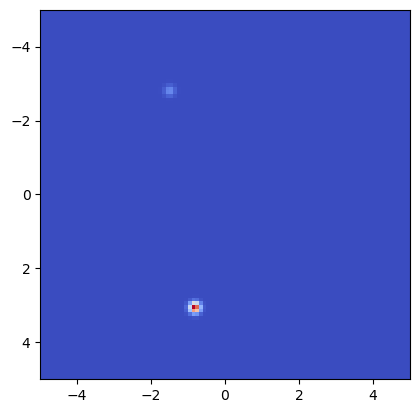

In [13]:
fig, ax = plt.subplots()
im = plt.imshow(scaled_var_to_show[0], extent=(x_coords[0], x_coords[-1], y_coords[-1], y_coords[0]), cmap='coolwarm')
ax.set_aspect('equal', adjustable='box')
display_handle = display(fig, display_id=True)
for time in range(scaled_var_to_show.shape[0]):
    im.set_data(scaled_var_to_show[time])
    display_handle.update(fig)
plt.close()

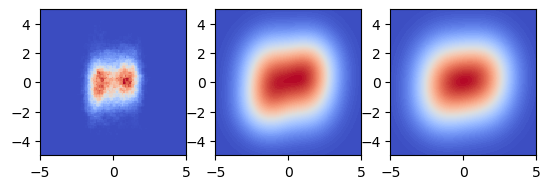

In [43]:
beta_c = landscape.get_beta_crit()
beta_c_idx = torch.argmin(torch.abs(betas-beta_c))
best_ov_idx = np.argmax(np.sum(hist2d[0][None,:,:]*q_beta.numpy(), axis=(1,2))*float(dx*dy))
fig, axs = plt.subplots(ncols=3)
hist2d = axs[0].hist2d(xy[:,0],xy[:,1], bins=(np.linspace(x_coords[0], x_coords[-1], len(x_coords)+1), np.linspace(y_coords[0], y_coords[-1], len(y_coords)+1)), density=True, cmap='coolwarm')
axs[1].contourf(x_grid,y_grid,q_beta[beta_c_idx], levels=100,cmap='coolwarm')
axs[2].contourf(x_grid,y_grid,q_beta[best_ov_idx], levels=100,cmap='coolwarm')
#with torch.no_grad():
#    plt.scatter(landscape.patterns[:,0], landscape.patterns[:,1], c=torch.softmax(landscape.biases, dim=0), cmap='coolwarm')
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
axs[2].set_aspect('equal')
plt.show()